![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [3]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [4]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [12]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [11]:
# Análisis exploratorio
print('\ndf info:')
print(data.info())
print('\ndf describe:')
print(data.describe().round())


df info:
<class 'pandas.core.frame.DataFrame'>
Index: 10495 entries, 7 to 399976
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Price        10495 non-null  int64
 1   Year         10495 non-null  int64
 2   Mileage      10495 non-null  int64
 3   M_Camry      10495 non-null  bool 
 4   M_Camry4dr   10495 non-null  bool 
 5   M_CamryBase  10495 non-null  bool 
 6   M_CamryL     10495 non-null  bool 
 7   M_CamryLE    10495 non-null  bool 
 8   M_CamrySE    10495 non-null  bool 
 9   M_CamryXLE   10495 non-null  bool 
dtypes: bool(7), int64(3)
memory usage: 399.7 KB
None

df describe:
         Price     Year   Mileage
count  10495.0  10495.0   10495.0
mean   14538.0   2014.0   52509.0
std     3922.0      3.0   36792.0
min     5002.0   1998.0       5.0
25%    11999.0   2012.0   26461.0
50%    15000.0   2014.0   41680.0
75%    16999.0   2016.0   71356.0
max    32444.0   2018.0  232658.0


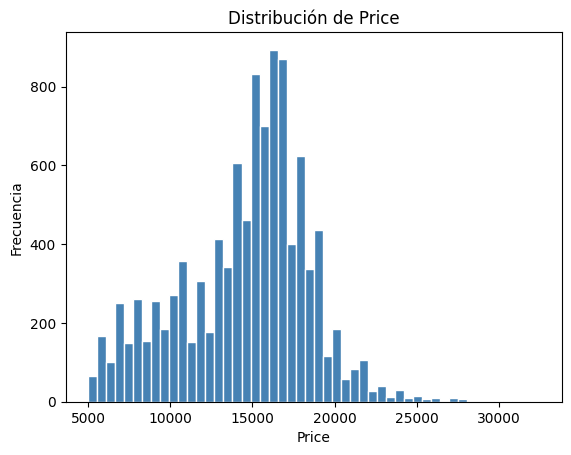

In [27]:
# Distribución de Price
plt.hist(data['Price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribución de Price')
plt.xlabel('Price')
plt.ylabel('Frecuencia')
plt.show()

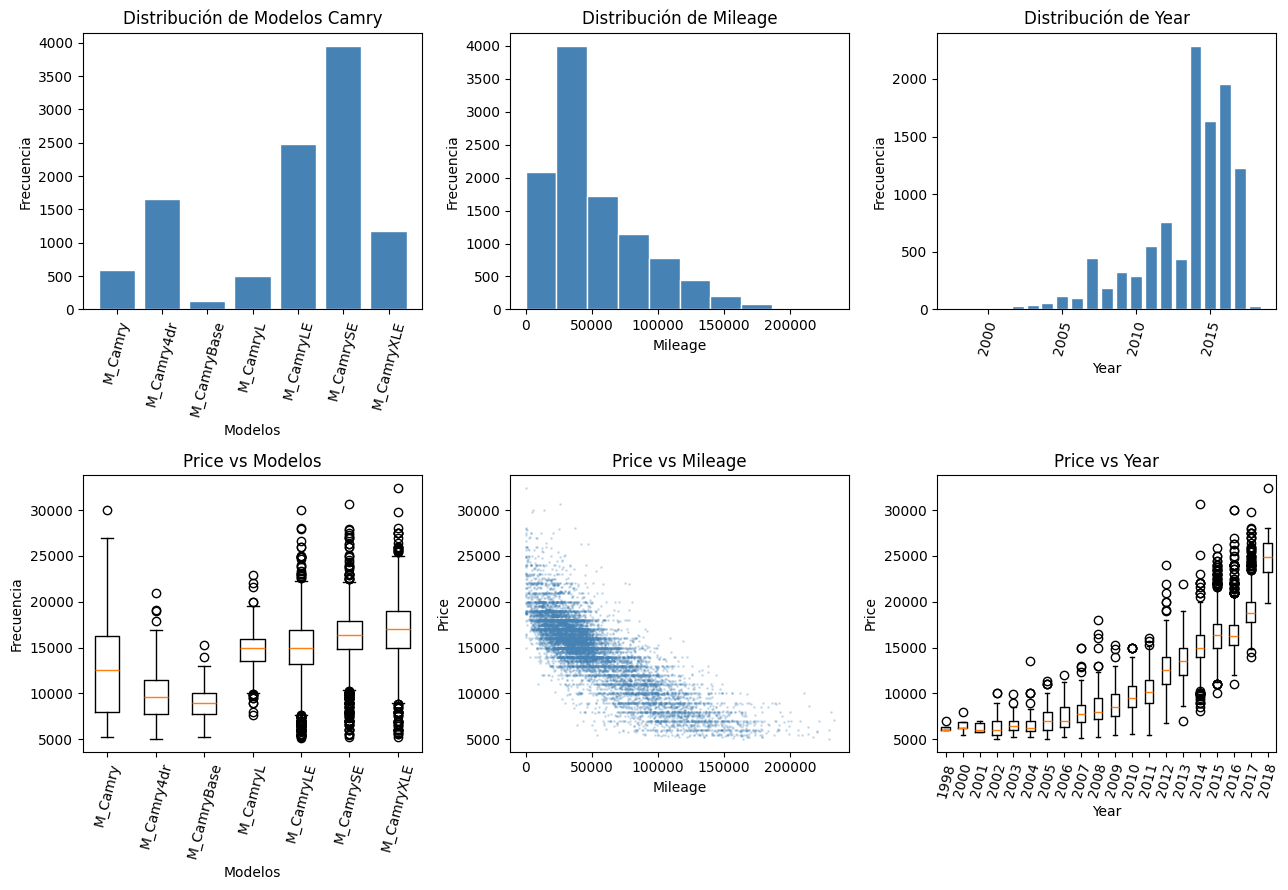

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(13, 9))

# Distribución de modelos Camry
camry_cols = [col for col in data.columns if 'Camry' in col]
counts = data[camry_cols].sum()
axes[0, 0].bar(counts.index, counts, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribución de Modelos Camry')
axes[0, 0].set_xlabel('Modelos')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].tick_params(axis='x', rotation=75)

# Distribución de Mileage
axes[0, 1].hist(data['Mileage'], color='steelblue', edgecolor='white')
axes[0, 1].set_title('Distribución de Mileage')
axes[0, 1].set_xlabel('Mileage')
axes[0, 1].set_ylabel('Frecuencia')

# Distribución de Year
year_counts = data['Year'].value_counts().sort_index()
axes[0, 2].bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='white')
axes[0, 2].set_title('Distribución de Year')
axes[0, 2].set_xlabel('Year')
axes[0, 2].set_ylabel('Frecuencia')
axes[0, 2].tick_params(axis='x', rotation=75)

# Price vs modelo
data_to_plot = [data.loc[data[col] == True, 'Price'] for col in camry_cols]
axes[1, 0].boxplot(data_to_plot, labels=camry_cols)
axes[1, 0].set_title('Price vs Modelos')
axes[1, 0].set_xlabel('Modelos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].tick_params(axis='x', rotation=75)

# Price vs Mileage
axes[1, 1].scatter(data['Mileage'], data['Price'], alpha=0.2, color='steelblue', s=1)
axes[1, 1].set_title('Price vs Mileage')
axes[1, 1].set_xlabel('Mileage')
axes[1, 1].set_ylabel('Price')

# Price vs Year (boxplot)
years = sorted(data['Year'].unique())
data_by_year = [data[data['Year'] == y]['Price'].values for y in years]
axes[1, 2].boxplot(data_by_year, labels=years)
axes[1, 2].set_title('Price vs Year')
axes[1, 2].set_xlabel('Year')
axes[1, 2].set_ylabel('Price')
axes[1, 2].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

El precio de los vehículos está principalmente explicado por el kilometraje, la antigüedad y la versión del modelo. Se observa una relación negativa con el uso, positiva con el año, y diferencias claras entre versiones.

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [35]:
# Árbol de decisión manual

def variance_reduction(X_col, y, split):
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    n_l, n_r = y_l.shape[0], y_r.shape[0]
    if n_l == 0 or n_r == 0:
        return 0
    return y.var() - (n_l / (n_l + n_r)) * y_l.var() - (n_r / (n_l + n_r)) * y_r.var()

def best_split(X, y, num_pct=10):
    best = [0, 0, 0]
    for j in range(X.shape[1]):
        splits = np.unique(np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / num_pct).tolist()))
        for split in splits:
            gain = variance_reduction(X.iloc[:, j], y, split)
            if gain > best[2]:
                best = [j, split, gain]
    return best

def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    if X.shape[0] == 1 or y.nunique() == 1:
        return dict(y_pred=y.mean(), level=level, split=-1, n_samples=X.shape[0], gain=0)
    j, split, gain = best_split(X, y, num_pct)
    tree = dict(y_pred=y.mean(), level=level, split=-1, n_samples=X.shape[0], gain=gain)
    if gain < min_gain or (max_depth is not None and level >= max_depth):
        return tree
    filter_l = X.iloc[:, j] < split
    tree['split'] = [j, split]
    tree['sl'] = tree_grow(X.loc[filter_l], y.loc[filter_l], level + 1, min_gain, max_depth, num_pct)
    tree['sr'] = tree_grow(X.loc[~filter_l], y.loc[~filter_l], level + 1, min_gain, max_depth, num_pct)
    return tree

def tree_predict(tree, X):
    predictions = []
    for i in range(X.shape[0]):
        node = tree
        while node['split'] != -1:
            j, split = node['split']
            node = node['sl'] if X.iloc[i, j] < split else node['sr']
        predictions.append(node['y_pred'])
    return np.array(predictions)

In [36]:
# Entrenar árbol manual
X_train_ = X_train.astype(float)
X_test_ = X_test.astype(float)

# Entrenamiento
tree = tree_grow(X_train_, y_train, level=0, min_gain=0.001, max_depth=5, num_pct=10)

# Predicciones y métricas
y_pred_DT = tree_predict(tree, X_test_)

RMSE_DT = np.sqrt(mean_squared_error(y_test, y_pred_DT))
MAE_DT = mean_absolute_error(y_test, y_pred_DT)
print(f'RMSE: {RMSE_DT:.2f}')
print(f'MAE: {MAE_DT:.2f}')

RMSE: 1720.51
MAE: 1290.40


Se construyó un árbol de decisión desde cero como modelo base de referencia. El modelo obtuvo un RMSE de \$1,720.51, lo que significa que en promedio las predicciones se alejan \$1,720 del precio real del automóvil. Al ser un único árbol sin mecanismo de corrección, este resultado era esperado y sirve como punto de comparación para los modelos siguientes.

### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [37]:
# Bagging manual

# Definición del número de observaciones y árboles
np.random.seed(123)
n_samples = X_train.shape[0]
n_B = 10

# Creación de 10 muestras bootstrap con reemplazo
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(1, n_B + 1)]

# DataFrame para guardar las predicciones de cada árbol
y_pred_bag = pd.DataFrame(index=X_test.index, columns=list(range(n_B)))

# Entrenamiento de un árbol sobre cada muestra bootstrap y predicciones
for i, sample in enumerate(samples):
    X_b = X_train_.iloc[sample]
    y_b = y_train.iloc[sample]
    tree_b = tree_grow(X_b, y_b, level=0, min_gain=0.001, max_depth=5, num_pct=10)
    y_pred_bag.iloc[:, i] = tree_predict(tree_b, X_test_)

for i in range(n_B):
    print(f'Árbol {i} tiene un error: {np.sqrt(mean_squared_error(y_test, y_pred_bag.iloc[:, i])):.2f}')

y_pred_BM = y_pred_bag.mean(axis=1)

Árbol 0 tiene un error: 1684.94
Árbol 1 tiene un error: 1721.14
Árbol 2 tiene un error: 1710.97
Árbol 3 tiene un error: 1735.49
Árbol 4 tiene un error: 1727.15
Árbol 5 tiene un error: 1699.57
Árbol 6 tiene un error: 1695.37
Árbol 7 tiene un error: 1697.81
Árbol 8 tiene un error: 1697.40
Árbol 9 tiene un error: 1716.39


In [38]:
# Calculo de métricas de desempeño
RMSE_BM = np.sqrt(mean_squared_error(y_test, y_pred_BM))
MAE_BM = mean_absolute_error(y_test, y_pred_BM)
print(f'RMSE: {RMSE_BM:.2f}')
print(f'MAE: {MAE_BM:.2f}')

RMSE: 1630.88
MAE: 1212.28


Se entrenaron 10 árboles sobre muestras bootstrap distintas y se promediaron sus predicciones. El RMSE bajó a \$1,630.88, una mejora de \$90 respecto al árbol individual. Esto confirma la idea central del bagging: los errores de cada árbol se compensan entre sí al combinar las predicciones, logrando un modelo más estable y preciso.

### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [39]:
# Bagging con librería

# Definición del modelo
model_bagreg = BaggingRegressor(DecisionTreeRegressor(max_features='log2'), n_estimators=120,
                          bootstrap=True, oob_score=True, random_state=1)

# Entrenamiento del modelo
model_bagreg.fit(X_train, y_train)

# Realizar predicciones
y_pred_bagreg = model_bagreg.predict(X_test)

# Calculo de metricas de desempeño
RMSE_bagreg = np.sqrt(mean_squared_error(y_test, y_pred_bagreg))
MAE_bagreg = mean_absolute_error(y_test, y_pred_bagreg)
print(f'MSE: {RMSE_bagreg:.2f}')
print(f'MAE: {MAE_bagreg:.2f}')

MSE: 1788.79
MAE: 1335.22


Se implementó bagging usando la librería sklearn con restricción de variables por log2. El RMSE fue de \$1,788.79, mostrando un desempeño peor que el bagging anterior. La restricción de variables perjudicó la precisión individual de cada árbol más de lo que la diversidad entre ellos pudo compensar, lo que sugiere que para este dataset limitar las variables disponibles en cada split no fue una estrategia beneficiosa.

### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [40]:
# Random forest con librería

# Definción del modelo
model_RF = RandomForestRegressor()

# Entrenamiento del modelo
model_RF.fit(X_train, y_train)

# Predicciones en grupo de validación
y_pred_RF = model_RF.predict(X_test)

# Cálculo de métricas de desempeño
RMSE_RF = np.sqrt(mean_squared_error(y_test, y_pred_RF))
MAE_RF = mean_absolute_error(y_test, y_pred_RF)
print(f'RMSE: {RMSE_RF:.2f}')
print(f'MAE: {MAE_RF:.2f}')

RMSE: 1757.48
MAE: 1309.21


Se entrenó un Random Forest con parámetros por defecto. El RMSE fue de \$1,757.48, mejor que el bagging sklearn pero inferior al bagging manual. Aunque el Random Forest introduce aleatoriedad adicional en la selección de variables para mejorar la diversidad entre árboles, sin calibración no logra aprovechar ese potencial completamente.

### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

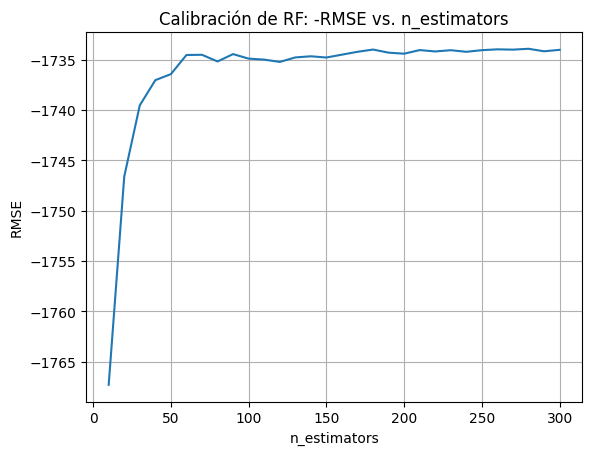

In [41]:
# Calibración de parámetros Random forest

# Se realiza primero una calibración individual para cada uno de los hyper-parámetros.
# Posteriormente se realiza una búsqueda del mejor modelo con GridSearchCV alrededor de los valores encontrados de forma independiente para cada hyper-parámetro.

# n_estimators
estimator_range = range(10, 310, 10)
accuracy_scores = []
for estimator in estimator_range:
    model_RF_ = RandomForestRegressor(n_estimators=estimator, random_state=1, n_jobs=-1)
    accuracy_scores.append(cross_val_score(model_RF_, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean())

plt.plot(estimator_range, accuracy_scores)
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('Calibración de RF: -RMSE vs. n_estimators')
plt.grid()
plt.show()

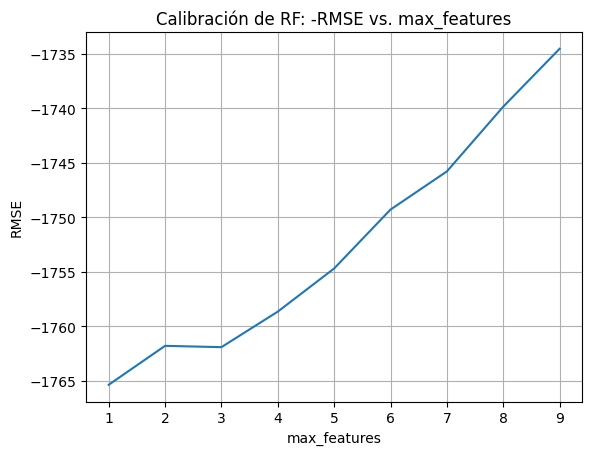

In [42]:
# max_features
feature_range = range(1, X_train.shape[1] + 1)
accuracy_scores = []
for feature in feature_range:
    model_RF_ = RandomForestRegressor(n_estimators=70, max_features=feature, random_state=1, n_jobs=-1)
    accuracy_scores.append(cross_val_score(model_RF_, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean())

plt.plot(feature_range, accuracy_scores)
plt.xlabel('max_features')
plt.ylabel('RMSE')
plt.title('Calibración de RF: -RMSE vs. max_features')
plt.grid()
plt.show()

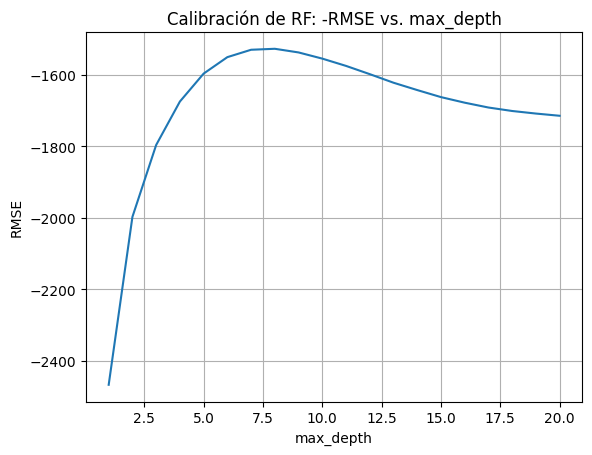

In [43]:
# max_depth
depth_range = range(1, 21)
accuracy_scores = []
for depth in depth_range:
    model_RF_ = RandomForestRegressor(n_estimators=90, max_features=9, max_depth=depth, random_state=1, n_jobs=-1)
    accuracy_scores.append(cross_val_score(model_RF_, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean())

plt.plot(depth_range, accuracy_scores)
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('Calibración de RF: -RMSE vs. max_depth')
plt.grid()
plt.show()

In [44]:
# GridSearchCV

# Conjunto de valores a considerar
param_grid = {
    'n_estimators': [70, 80, 90],
    'max_depth': [6, 7, 8],
    'max_features': [7, 8]
}

# Definición del modelo
model_RF_ = RandomForestRegressor(random_state=1, n_jobs=-1)

# Definición y ejecución de GridSearchCV
grid = GridSearchCV(
    estimator=model_RF_,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'max_depth': 8, 'max_features': 7, 'n_estimators': 70}


In [45]:
# Selección del mejor modelo
best_rf = grid.best_estimator_

# Predicciones sobre conjunto de validación
y_pred_RF_c = best_rf.predict(X_test)

# Cálculo de métricas de desempeño
RMSE_RF_c = np.sqrt(mean_squared_error(y_test, y_pred_RF_c))
MAE_RF_c = mean_absolute_error(y_test, y_pred_RF_c)
print(f'RMSE: {RMSE_RF_c:.2f}')
print(f'MAE: {MAE_RF_c:.2f}')

RMSE: 1557.64
MAE: 1144.47


Mediante la optimización de n_estimators, max_features y max_depth se logró un RMSE de \$1,557.64, obteniendo una reducción de aprox. 11% con respecto al RF sin calibrar. La calibración mostró que más árboles ayudan hasta cierto punto, que existe un balance óptimo en cuántas variables considerar por split y que la profundidad debe controlarse para evitar que los árboles aprendan ruido en lugar de patrones reales.

### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [46]:
# XGBoost con librería

# Definición del modelo
model_XGB = XGBRegressor()

# Entrenamiento del modelo
model_XGB.fit(X_train, y_train)

# Predicciones en grupo de validación
y_pred_XGB = model_XGB.predict(X_test)

# Cálculo de métricas de desempeño
RMSE_XGB = np.sqrt(mean_squared_error(y_test, y_pred_XGB))
MAE_XGB = mean_absolute_error(y_test, y_pred_XGB)
print(f'RMSE: {RMSE_XGB:.2f}')
print(f'MAE: {MAE_XGB:.2f}')

RMSE: 1605.24
MAE: 1185.23


Se entrenó un modelo XGBoost con parámetros por defecto obteniendo un RMSE de \$1,605.24. A diferencia del bagging y Random Forest, que construyen árboles de forma independiente y combinan sus resultados, XGBoost los construye secuencialmente: cada árbol aprende de los errores que cometió el anterior. Esta capacidad de autocorrección progresiva explica por qué, incluso sin ningún ajuste de parámetros, el modelo logra un desempeño competitivo frente a modelos anteriores que sí fueron calibrados.

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

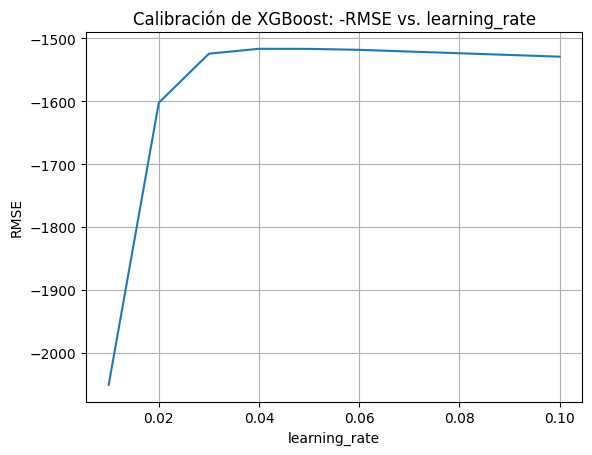

In [47]:
# Celda 7

# Se realiza primero una calibración individual para cada uno de los hyper-parámetros.
# Posteriormente se realiza una búsqueda del mejor modelo con GridSearchCV alrededor de los valores encontrados de forma independiente para cada hyper-parámetro.

# learning rate
learning_rate_range = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.1]
accuracy_scores = []
for lr in learning_rate_range:
    model_XGB_c = XGBRegressor(learning_rate=lr, random_state=1)
    accuracy_scores.append(cross_val_score(model_XGB_c, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean())

plt.plot(learning_rate_range, accuracy_scores)
plt.xlabel('learning_rate')
plt.ylabel('RMSE')
plt.title('Calibración de XGBoost: -RMSE vs. learning_rate')
plt.grid()
plt.show()

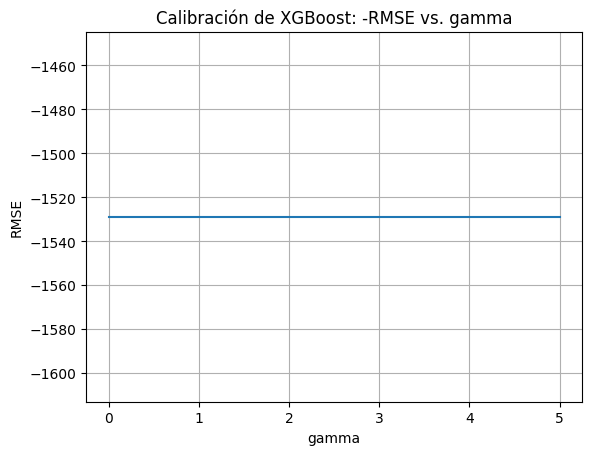

In [48]:
# gamma
gamma_range = [0, 0.1, 0.5, 1, 2, 5]
accuracy_scores = []
for gamma in gamma_range:
    model_XGB_ = XGBRegressor(learning_rate=0.1, gamma=gamma, random_state=1)
    accuracy_scores.append(cross_val_score(model_XGB_, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean())

plt.plot(gamma_range, accuracy_scores)
plt.xlabel('gamma')
plt.ylabel('RMSE')
plt.title('Calibración de XGBoost: -RMSE vs. gamma')
plt.grid()
plt.show()

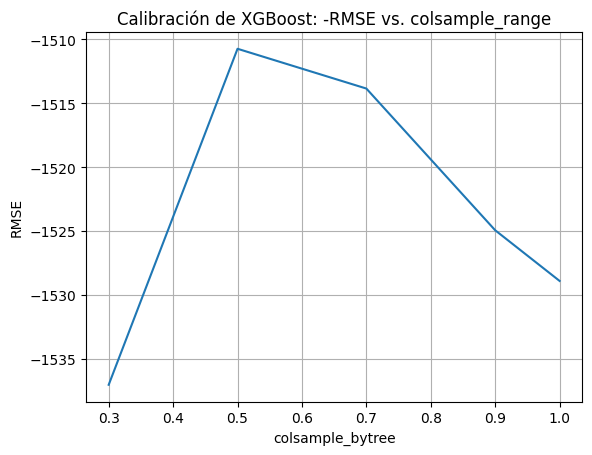

In [49]:
# colsample_bytree
colsample_range = [0.3, 0.5, 0.7, 0.9, 1.0]
accuracy_scores = []
for colsample in colsample_range:
    model_XGB_ = XGBRegressor(learning_rate=0.1, gamma=0, colsample_bytree=colsample, random_state=1)
    accuracy_scores.append(cross_val_score(model_XGB_, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean())

plt.plot(colsample_range, accuracy_scores)
plt.xlabel('colsample_bytree')
plt.ylabel('RMSE')
plt.title('Calibración de XGBoost: -RMSE vs. colsample_range')
plt.grid()
plt.show()

In [50]:
# GridSearchCV

# Modelo base
model_XGB_c = XGBRegressor(random_state=1)

# Definición de Grid
param_grid = {
    'learning_rate': [0.04, 0.06, 0.1],
    'gamma': [0, 0.1],
    'colsample_bytree': [0.5, 0.7, 0.9]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=model_XGB_c,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid.fit(X_train, y_train)

# Resultados
print("Best params:", grid.best_params_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.06}


In [51]:
# Selección del mejor modelo
best_xgb = grid.best_estimator_

# Predicciones sobre conjunto de validación
y_pred_XGB_c = best_xgb.predict(X_test)

# Cálculo de métricas de desempeño
RMSE_XGB_c = np.sqrt(mean_squared_error(y_test, y_pred_XGB_c))
MAE_XGB_c = mean_absolute_error(y_test, y_pred_XGB_c)
print(f'RMSE: {RMSE_XGB_c:.2f}')
print(f'MAE: {MAE_XGB_c:.2f}')

RMSE: 1547.35
MAE: 1135.68


Al optimizar learning_rate, gamma y colsample_bytree, XGBoost alcanzó el mejor resultado del taller con un RMSE de \$1,547.35. La calibración afinó tres aspectos clave del modelo: la velocidad de aprendizaje, el nivel de regularización para evitar sobreajuste, y la diversidad entre árboles mediante la selección aleatoria de variables.

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

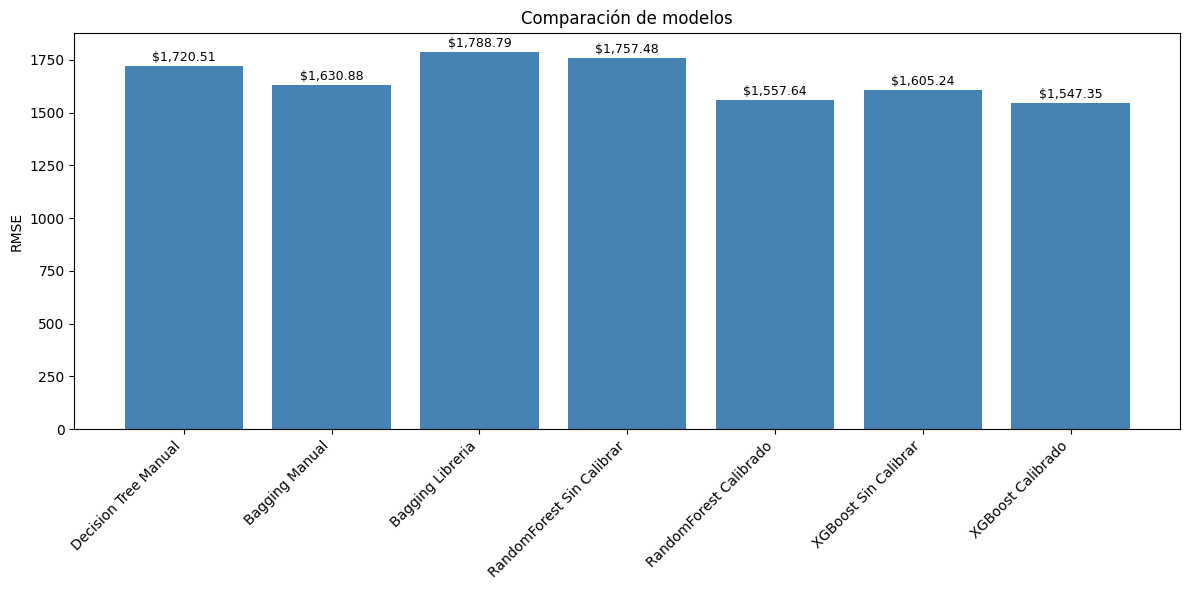

In [52]:
# Comparación y análisis de resultados

modelos = ['Decision Tree Manual', 'Bagging Manual', 'Bagging Libreria',
           'RandomForest Sin Calibrar', 'RandomForest Calibrado',
           'XGBoost Sin Calibrar', 'XGBoost Calibrado']
rmse_values = [RMSE_DT, RMSE_BM, RMSE_bagreg, RMSE_RF, RMSE_RF_c, RMSE_XGB, RMSE_XGB_c]

plt.figure(figsize=(12, 6))
bars = plt.bar(modelos, rmse_values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('RMSE')
plt.title('Comparación de modelos')

for bar, rmse in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'${rmse:,.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

XGBoost calibrado fue el modelo con mejor rendimiento ya que obtuvo un RMSE de \$1,547.35, seguido de cerca por el Random Forest calibrado con \$1,557.64. El modelo con peor desempeño fue el Bagging de sklearn con \$1,788.79.

Del ejercicio se resalta lo siguiente:
1. La calibración fue determinante, mejorando el RF un 11% y XGBoost un 4%.
2. El bagging manual superó al bagging sklearn y al RF sin calibrar, lo que indica que para este dataset usar todas las variables disponibles en cada split fue más beneficioso que introducir restricciones artificiales de aleatoriedad.